<a href="https://colab.research.google.com/github/shengFung/WIF3009/blob/main/WIF3009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📦 Dataset Installation & Preparation (Kaggle + Data Engineering)

## 🎯 Objective
The goal of this step is to build a **structured dataset** for a multi-agent AI system that predicts clothing prices.  
This involves:
- Downloading raw data
- Engineering missing labels (price & condition)
- Linking images
- Cleaning and validating the dataset





## 🧩 1. Dataset Acquisition (Kaggle)

We use the **Fashion Product Images Dataset** from Kaggle as the base dataset.

### What happens:
- The dataset is downloaded programmatically using `kagglehub`
- It is stored in a local cache directory
- The main metadata file (`styles.csv`) is loaded into a DataFrame

### Why this is important:
- Provides **real product metadata** (brand, category, color, etc.)
- Saves time compared to manual scraping
- Gives a strong foundation for further data engineering



## 🧠 2. Data Engineering (Creating Target Labels)

The original dataset **does NOT contain price or condition**, so we generate them.

### 🔹 Price Generation
A rule-based pricing system is applied:
- Each clothing category (e.g., T-shirts, Jackets, Hoodies) has a **base price**
- Example:
  - Jackets → higher base price
  - T-shirts → lower base price

Then:
- Price is adjusted using a **condition multiplier**
- Random noise is added to simulate real-world variation

👉 This creates a realistic **target variable (price)** for machine learning



### 🔹 Condition Generation
Each item is randomly assigned:
- New
- Used
- Worn

With probabilities:
- Used (most common)
- New and Worn (less frequent)

👉 This simulates real resale market conditions (like eBay/Grailed)



## 🖼️ 3. Image Path Mapping

Each product is linked to its corresponding image file.

### What happens:
- The system constructs the full file path using the product ID
- Example: `/kaggle/input/fashion-product-images-small/images/15970.jpg`


### Why this matters:
- Enables the **Image Agent (Person C)** to process visual features
- Ensures every data record has an associated image


## 🧹 4. Dataset Structuring

Only relevant columns are kept for the project:

### Final dataset includes:
- ID
- Image path
- Product name (text description)
- Gender
- Category information
- Color
- Price (generated)
- Condition (generated)

👉 This ensures the dataset matches your **multi-agent system requirements**

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os

def build_project_dataset():
    print("Step 1: Downloading dataset from Kaggle...")
    # This downloads the files to a local cache folder
    path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
    print(f"✅ Dataset downloaded to: {path}")

    # 1. Load the metadata
    # The CSV is usually named 'styles.csv' inside the downloaded path
    csv_path = os.path.join(path, 'styles.csv')

    try:
        # on_bad_lines='skip' handles occasional formatting errors in the original file
        df = pd.read_csv(csv_path, on_bad_lines='skip')
        print(f"✅ Loaded {len(df)} initial records.")
    except Exception as e:
        print(f"❌ Error loading CSV: {e}")
        return

    # 2. Data Engineering - Create Price & Condition
    # We need a 'Target Label' for our multi-agent system to predict
    print("Step 2: Engineering Price and Condition labels...")

    def generate_market_data(row):
        # Base pricing logic based on category
        base_prices = {
            'Tshirts': 45.0,
            'Shirts': 65.0,
            'Jackets': 180.0,
            'Hoodies': 95.0,
            'Pants': 75.0,
            'Shoes': 120.0
        }

        # Get base price or default to 50
        price = base_prices.get(row['articleType'], 50.0)

        # Add random "Condition"
        condition = np.random.choice(['New', 'Used', 'Worn'], p=[0.2, 0.6, 0.2])

        # Adjust price based on condition
        cond_multiplier = {'New': 1.4, 'Used': 0.9, 'Worn': 0.5}
        price *= cond_multiplier[condition]

        # Add noise (simulating market fluctuations)
        price += np.random.normal(0, 10)

        return round(max(10, price), 2), condition

    # Apply the logic
    prices_and_conditions = df.apply(generate_market_data, axis=1)
    df['price'], df['condition'] = zip(*prices_and_conditions)

    # 3. Map Image Paths
    # We need the full path to the images for Person C (Image Agent)
    df['image_path'] = df['id'].apply(lambda x: os.path.join(path, 'images', f"{x}.jpg"))

    # 4. Final Cleanup
    # Keep only the columns your team actually needs
    cols_to_keep = ['id', 'image_path', 'productDisplayName', 'gender', 'masterCategory',
                    'subCategory', 'articleType', 'baseColour', 'price', 'condition']
    df_final = df[cols_to_keep]

    # Save to your working directory
    output_name = "final_clothing_dataset.csv"
    df_final.to_csv(output_name, index=False)

    print("-" * 30)
    print(f"🏁 DATASET READY FOR THE TEAM!")
    print(f"Total Records: {len(df_final)}")
    print(f"CSV File: {output_name}")
    print(f"Image Folder: {os.path.join(path, 'images')}")
    print("-" * 30)
    print(df_final.head())

    return df_final # Explicitly return the DataFrame

df = build_project_dataset()

Step 1: Downloading dataset from Kaggle...
Using Colab cache for faster access to the 'fashion-product-images-small' dataset.
✅ Dataset downloaded to: /kaggle/input/fashion-product-images-small
✅ Loaded 44424 initial records.
Step 2: Engineering Price and Condition labels...
------------------------------
🏁 DATASET READY FOR THE TEAM!
Total Records: 44424
CSV File: final_clothing_dataset.csv
Image Folder: /kaggle/input/fashion-product-images-small/images
------------------------------
      id                                         image_path  \
0  15970  /kaggle/input/fashion-product-images-small/ima...   
1  39386  /kaggle/input/fashion-product-images-small/ima...   
2  59263  /kaggle/input/fashion-product-images-small/ima...   
3  21379  /kaggle/input/fashion-product-images-small/ima...   
4  53759  /kaggle/input/fashion-product-images-small/ima...   

                              productDisplayName gender masterCategory  \
0               Turtle Check Men Navy Blue Shirt    Men  


## 🧼 5. Data Cleaning & Validation

To ensure high-quality data:

### 🔹 File Validation
- Check if image files actually exist on disk
- Remove rows with missing or broken images

### 🔹 Handle Missing Values
- Fill missing colors → "Unknown"
- Fill missing descriptions → "No Description"

### Why this is important:
- Prevents errors during model training
- Ensures consistency across all agents



## 💾 6. Final Output

The cleaned dataset is saved as:
`final_cleaned_dataset.csv`


### Dataset is now:
- ✅ Structured
- ✅ Cleaned
- ✅ Image-linked
- ✅ Ready for ML models


# 📊 Exploratory Data Analysis (EDA)

The cleaned dataset has been successfully loaded and is now ready for **Exploratory Data Analysis (EDA)**.

This dataset contains fashion product information, including:

- 🏷️ **Product Name**
- 👤 **Gender**
- 📂 **Category**
- 👕 **Article Type**
- 🎨 **Colour**
- 💰 **Price**
- ✅ **Condition**
- 🖼️ **Image Path**

---

## 🎯 Objective of EDA

The purpose of this EDA is to better understand the dataset before moving into the machine learning stage.  
In this section, we will:

- Analyze **price patterns**
- Compare different **product characteristics**
- Detect possible **outliers**
- Explore relationships between product features
- Prepare meaningful **visualizations** for further analysis

---



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create folder to save plots
os.makedirs("eda_plots", exist_ok=True)

In [ ]:
df = pd.read_csv("final_clothing_dataset.csv")

df.head()

## 🔎 2. Basic Dataset Inspection

This step provides a quick overview of the cleaned dataset, including:

- Dataset size: **rows and columns**
- Data types of each column
- Missing values
- Duplicate records
- Summary statistics

This helps confirm that the dataset is clean, consistent, and ready for **EDA and machine learning**.

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nBasic Statistics:")
df.describe()

## 💰 3. Price Distribution

The price distribution graph shows how product prices are spread across the dataset.

Most products fall within the **low to middle price range**, while only a small number of products have higher prices.

This helps us understand the overall pricing pattern and identify any possible **expensive or unusual price values**.

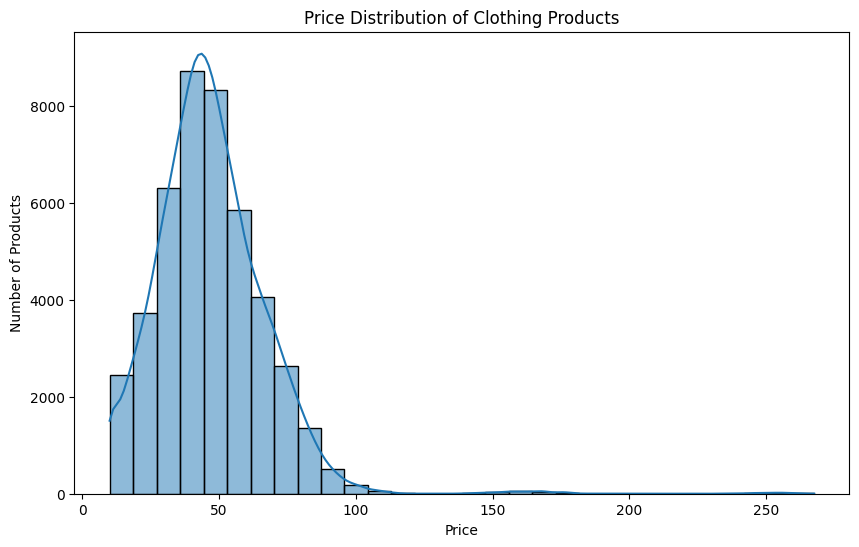

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df["price"], bins=30, kde=True)

plt.title("Price Distribution of Clothing Products")
plt.xlabel("Price")
plt.ylabel("Number of Products")

plt.savefig("eda_plots/price_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 🏷️ 4. Brand vs Price Analysis

This analysis compares the **average product price across different brands**.

Since the dataset does not include a separate brand column, the brand is estimated using the **first word of the product display name**.

This helps identify brands with generally **higher or lower average prices**.



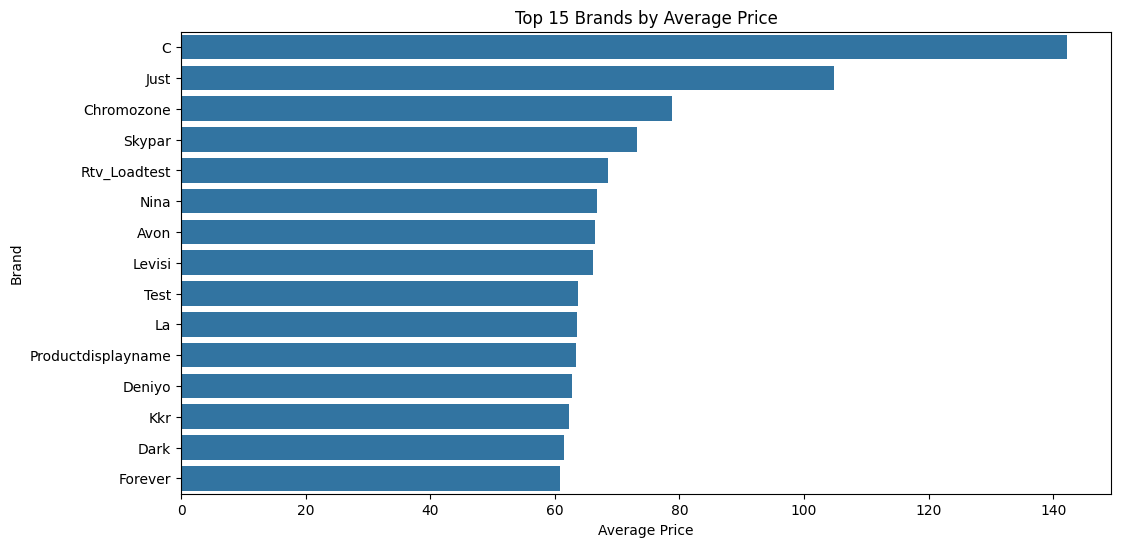

In [18]:
# If brand column does not exist, create one from productDisplayName
if "brand" not in df.columns:
    df["brand"] = df["productDisplayName"].astype(str).str.split().str[0].str.title()

df[["productDisplayName", "brand"]].head()

brand_price = (
    df.groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=brand_price.values, y=brand_price.index)

plt.title("Top 15 Brands by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Brand")

plt.savefig("eda_plots/brand_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

## ✅ 5. Condition vs Price Analysis

This analysis shows how **product condition affects price**.

In this dataset, **New** products generally have the highest prices, followed by **Used** products, while **Worn** products usually have lower prices.



,mean,median,min,max,count
condition,,,,,
New,71.358029,69.86,32.13,267.60,8944
Used,46.002714,45.12,10.00,187.78,26584
Worn,25.944170,25.37,10.00,116.57,8896


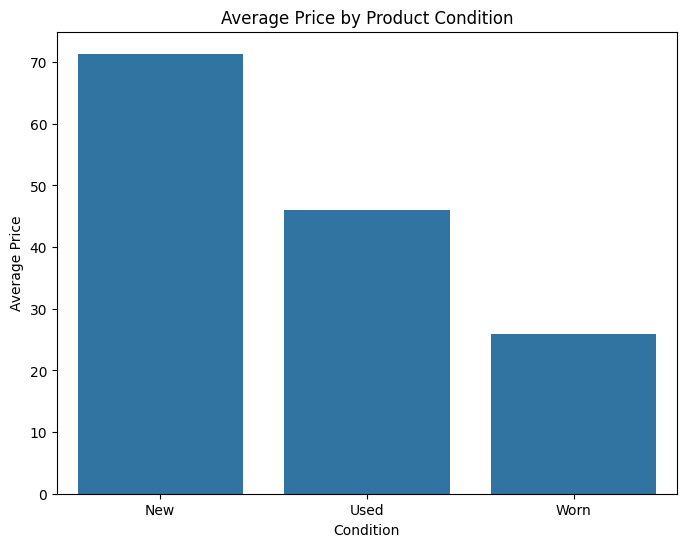

In [19]:

plt.figure(figsize=(8, 6))

condition_avg_price = df.groupby("condition")["price"].mean().reset_index()

sns.barplot(
    data=condition_avg_price,
    x="condition",
    y="price"
)

plt.title("Average Price by Product Condition")
plt.xlabel("Condition")
plt.ylabel("Average Price")

condition_price = df.groupby("condition")["price"].agg(["mean", "median", "min", "max", "count"])
condition_price

## 🔥 6. Correlation Heatmap

The correlation heatmap shows the relationship between **numerical variables** in the dataset.

The main focus is the **price** variable, as stronger positive or negative correlations may suggest which features are more related to product pricing.

The diagonal values are all 1.00 because each variable is perfectly correlated with itself.

For this analysis, categorical columns such as gender, product category, colour, condition, and brand were encoded into numerical values using factorization. This allows them to be included in the heatmap, but the results should be interpreted carefully because the assigned numbers do not always represent a true ranking or numerical meaning.

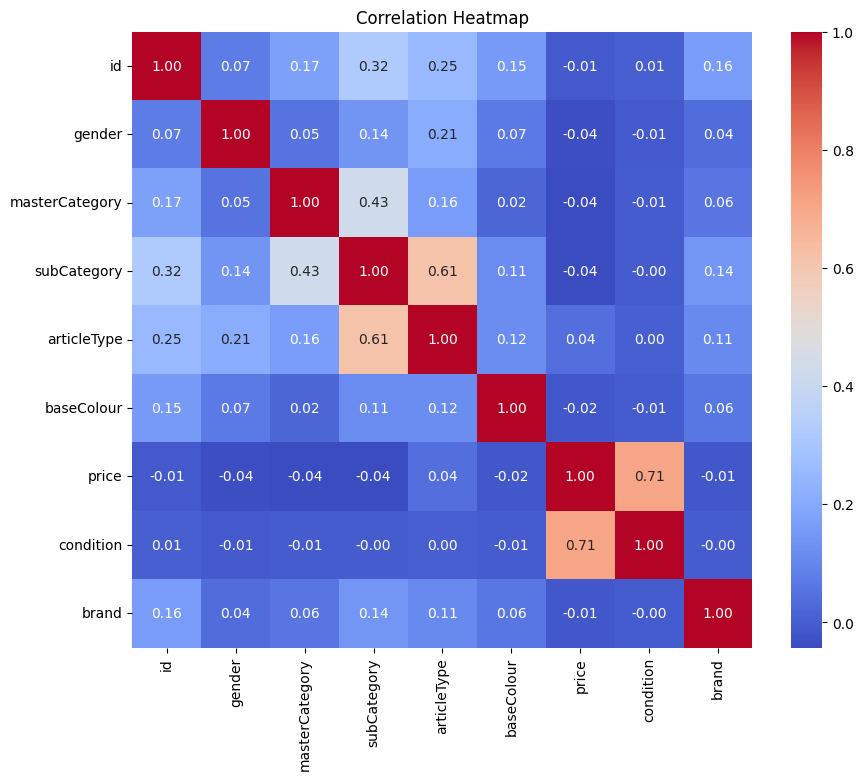

In [12]:
df_encoded = df.copy()

categorical_cols = ["gender", "masterCategory", "subCategory", "articleType", "baseColour", "condition", "brand"]

for col in categorical_cols:
    if col in df_encoded.columns:
        df_encoded[col] = pd.factorize(df_encoded[col])[0]

numeric_df = df_encoded.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.savefig("eda_plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## ⚠️ 7. Price Outlier Detection

Outlier detection is performed using the **Interquartile Range (IQR)** method.

The IQR method helps identify prices that are much **lower or higher than the normal range**.

These outliers may represent luxury items, rare products, generated price errors, or noisy data. Detecting them is important because extreme values can affect model performance and reduce **prediction accuracy**.

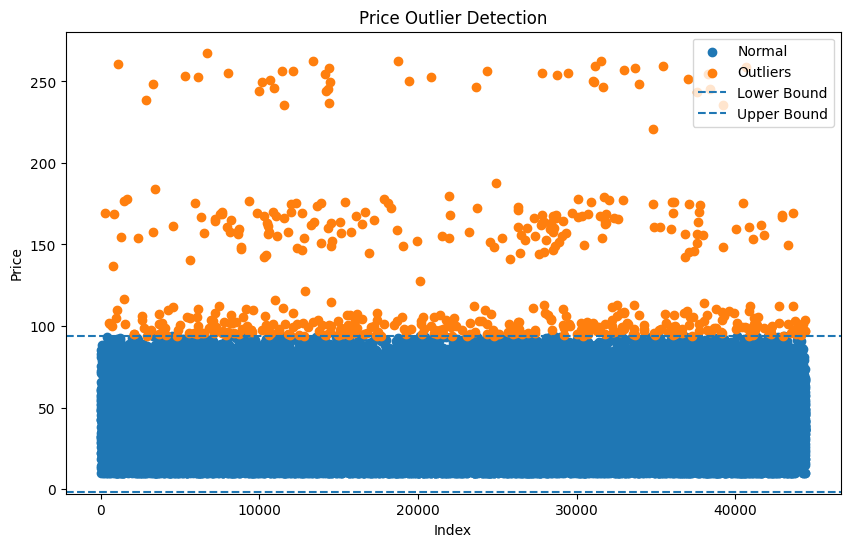

In [20]:
# 8. Outlier Detection Visualization using Scatter Plot

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
normal_data = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

plt.figure(figsize=(10, 6))

plt.scatter(normal_data.index, normal_data["price"], label="Normal")
plt.scatter(outliers.index, outliers["price"], label="Outliers")

plt.axhline(lower_bound, linestyle="--", label="Lower Bound")
plt.axhline(upper_bound, linestyle="--", label="Upper Bound")

plt.title("Price Outlier Detection")
plt.xlabel("Index")
plt.ylabel("Price")
plt.legend()

plt.savefig("eda_plots/outlier_detection_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# Save outliers
outliers.to_csv("price_outliers.csv", index=False)

## 👕 8. Article Type vs Price Analysis

This analysis compares the **average price across different article types**.

Different product types naturally have different market values. For example, **jackets and shoes** are usually more expensive than basic items like **t-shirts**.

This feature may be useful for machine learning because **article type** can help the model understand price differences between product categories.

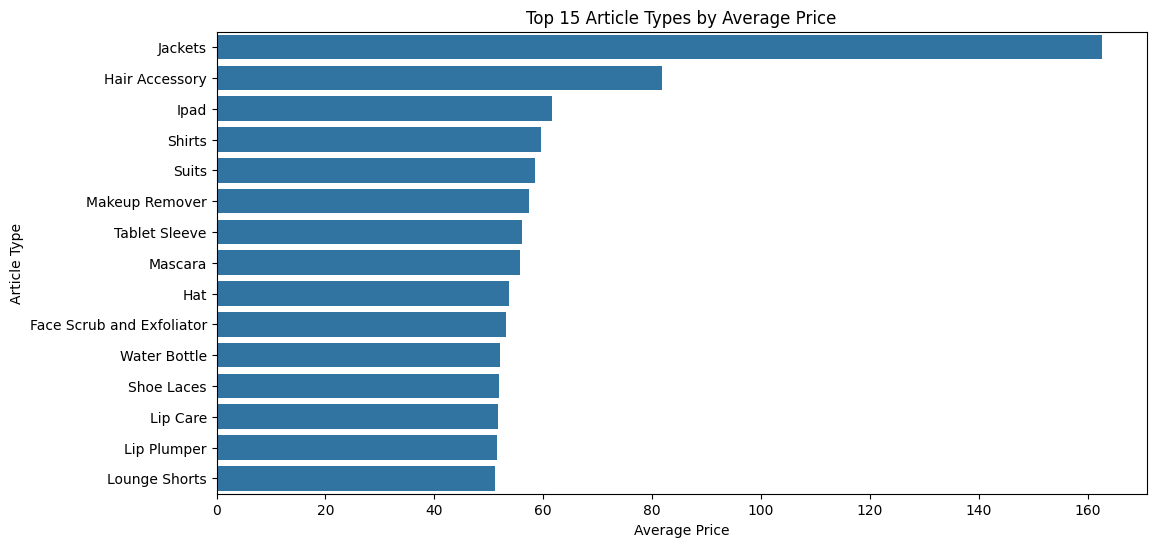

In [16]:
article_price = (
    df.groupby("articleType")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=article_price.values, y=article_price.index)

plt.title("Top 15 Article Types by Average Price")
plt.xlabel("Average Price")
plt.ylabel("Article Type")

plt.savefig("eda_plots/article_type_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()